### Импорт библиотек

In [33]:
import pandas as pd
import numpy as np

import re
import nltk
from nltk.corpus import stopwords
import pymorphy3
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

### Загрузка файлов

In [2]:
pos_df = pd.read_csv('pos.csv', sep=';', header=None, usecols=[3, 4], 
                     names=['text', 'sentiment'], encoding='utf-8', engine='python')
neg_df = pd.read_csv('neg.csv', sep=';', header=None, usecols=[3, 4], 
                    names=['text', 'sentiment'], encoding='utf-8', engine='python')

#### Включенные поля:
- text: Основной признак. Содержит лексико-семантическую информацию, необходимую для оценки эмоциональной окраски
- sentiment: Целевая переменная. Метка класса (1 — позитив, -1 — негатив)

#### Исключенные поля (исходные индексы 0, 1, 2, 5-11):
- tweet_id: Уникальный технический идентификатор. Не несет лингвистического смысла
- timestamp: Время публикации. Не определяет тональность текста
- username: Автор поста. Не влияет на семантику сообщения
- Метрики вовлеченности и служебные флаги (лайки, ретвиты, ответы). Не являются причиной тональности

### Создание датасетов с ключевыми колонками: текст поста и метка тональности

In [3]:
pos_df = pd.read_csv('pos.csv', sep=';', header=None, usecols=[3, 4], 
                     names=['text', 'sentiment'], encoding='utf-8', engine='python')
neg_df = pd.read_csv('neg.csv', sep=';', header=None, usecols=[3, 4], 
                     names=['text', 'sentiment'], encoding='utf-8', engine='python')

In [4]:
# Слияние классов в единую таблицу
dataset = pd.concat([pos_df, neg_df], ignore_index=True)

### Очистка от битых и пустых строк

In [5]:
# Очистка от битых/пустых строк
dataset.dropna(subset=['text'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

### Проверка итоговой структуры датасета

In [6]:
print("Названия колонок:", list(dataset.columns))
dataset.shape
dataset['sentiment'].value_counts()

Названия колонок: ['text', 'sentiment']


sentiment
 1    114911
-1    111923
Name: count, dtype: int64

In [7]:
dataset.head()

,text,sentiment
0,"@first_timee хоть я и школота, но поверь, у на...",1
1,"Да, все-таки он немного похож на него. Но мой ...",1
2,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1
3,"RT @digger2912: ""Кто то в углу сидит и погибае...",1
4,@irina_dyshkant Вот что значит страшилка :D\nН...,1


## Предварительная обработка текста

In [8]:
# Загрузка стоп-слов и инициализация анализатора
nltk.download('stopwords', quiet=True)
RU_STOPWORDS = set(stopwords.words('russian'))
MORPH = pymorphy3.MorphAnalyzer()

In [9]:
def preprocess_tweet(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+|t\.co/\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^а-яё\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    lemmatized = [
        MORPH.parse(w)[0].normal_form 
        for w in words 
        if w not in RU_STOPWORDS and len(w) > 2
    ]
    return ' '.join(lemmatized)

dataset['text_clean'] = dataset['text'].apply(preprocess_tweet)
dataset = dataset[dataset['text_clean'].str.len() > 0].reset_index(drop=True)

In [10]:
# Проверка результата
for i in range(3):
    print(f"Оригинал : {dataset['text'].iloc[i]}")
    print(f"Обработано: {dataset['text_clean'].iloc[i]}\n")

print(f"Записей после очистки: {len(dataset)}")

Оригинал : @first_timee хоть я и школота, но поверь, у нас то же самое :D общество профилирующий предмет типа)
Обработано: школотый поверь самый общество профилировать предмет тип

Оригинал : Да, все-таки он немного похож на него. Но мой мальчик все равно лучше:D
Обработано: всетаки немного похожий мальчик равно

Оригинал : RT @KatiaCheh: Ну ты идиотка) я испугалась за тебя!!!
Обработано: идиотка испугаться

Записей после очистки: 226200


## Тематическое моделирование положительных и отрицательных постов

In [11]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import warnings
warnings.filterwarnings('ignore')

## Облака слов

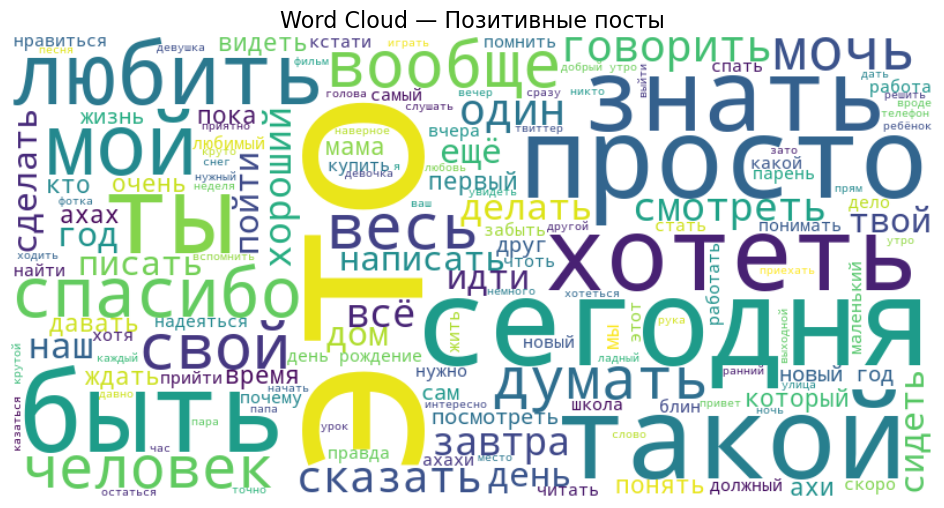

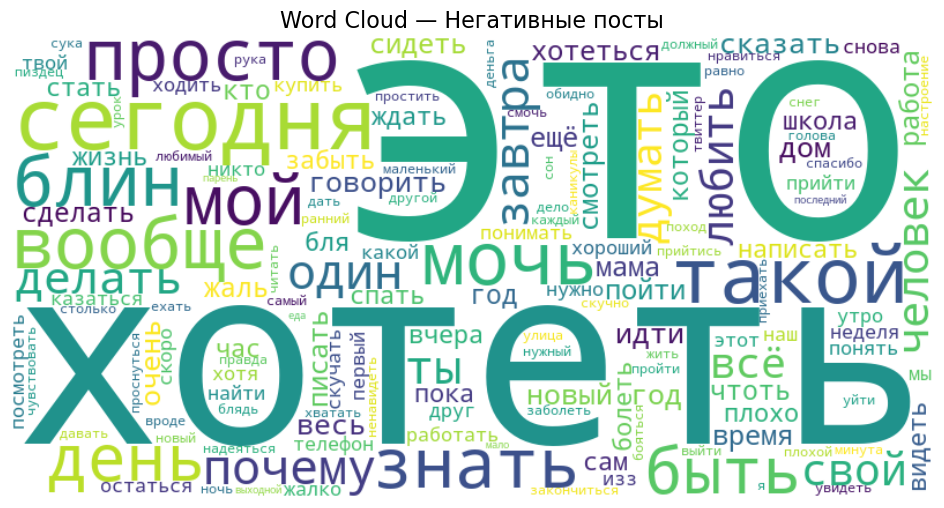

In [12]:
pos_text = ' '.join(dataset[dataset['sentiment'] == 1]['text_clean'])
neg_text = ' '.join(dataset[dataset['sentiment'] == -1]['text_clean'])

# Позитивные посты
plt.figure(figsize=(12, 6))
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(pos_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Позитивные посты', fontsize=16)
plt.show()

# Негативные посты
plt.figure(figsize=(12, 6))
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(neg_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Негативные посты', fontsize=16)
plt.show()

## Векторизация

In [13]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(dataset['text_clean'])
print(f"Размер TF-IDF матрицы: {X.shape}")

Размер TF-IDF матрицы: (226200, 5000)


In [14]:
feature_names = vectorizer.get_feature_names_out()
print("Примеры признаков:", feature_names[:50])

Примеры признаков: ['ааа' 'аааа' 'ааааа' 'аааааа' 'ааааааа' 'аааааааа' 'абсолютно' 'ава'
 'авария' 'аватарка' 'август' 'авто' 'автобус' 'автомат' 'автомобиль'
 'автор' 'ага' 'ад' 'адекватный' 'админ' 'адрес' 'адский' 'азаза'
 'азазаза' 'айпад' 'айпада' 'айса' 'айфон' 'академия' 'акк' 'аккаунт'
 'аккуратный' 'активно' 'активный' 'актриса' 'актуальный' 'актёр' 'акция'
 'алгебра' 'але' 'александр' 'ален' 'алина' 'алиса' 'алкоголь' 'аллергия'
 'альбом' 'алёна' 'америка' 'американец']


#### Пример вектора для одного документа

In [15]:
sample_idx = 0
sample_vector = X[sample_idx]
non_zero = sample_vector.nonzero()[1]
print("Токены в первом документе:", [feature_names[i] for i in non_zero[:10]])
print("Соответствующие веса:", sample_vector.data[:10])

Токены в первом документе: ['поверь', 'самый', 'общество', 'предмет', 'тип']
Соответствующие веса: [0.53800967 0.30623665 0.48434098 0.4726292  0.39849739]


## Тематическое моделирование

In [16]:
def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]]
        print(f"Тема {topic_idx}: {', '.join(top_words)}")

# Общий датасет
nmf = NMF(n_components=6, random_state=42)
nmf.fit(X)

print("\nТемы для всего датасета")
print_topics(nmf, vectorizer.get_feature_names_out())

# Позитивные посты
X_pos = vectorizer.transform(dataset[dataset['sentiment'] == 1]['text_clean'])
nmf_pos = NMF(n_components=5, random_state=42)
nmf_pos.fit(X_pos)

print("\nТемы позитивных постов")
print_topics(nmf_pos, vectorizer.get_feature_names_out())

# Негативные посты
X_neg = vectorizer.transform(dataset[dataset['sentiment'] == -1]['text_clean'])
nmf_neg = NMF(n_components=5, random_state=42)
nmf_neg.fit(X_neg)

print("\nТемы негативных постов")
print_topics(nmf_neg, vectorizer.get_feature_names_out())


Темы для всего датасета
Тема 0: это, просто, самый, думать, это просто, очень, человек, всё, время, мой
Тема 1: день, сегодня, весь, завтра, рождение, быть, день рождение, хороший, утро, мой
Тема 2: хотеть, спать, хотеть спать, блин, идти, посмотреть, мочь, никто, спать хотеть, хотеть хотеть
Тема 3: год, новый, новый год, настроение, скоро, ёлка, быть, новогодний, подарок, скоро новый
Тема 4: такой, человек, почему, мочь, просто, вообще, видеть, один, говорить, смотреть
Тема 5: ты, знать, любить, спасибо, очень, просто, быть, человек, сказать, говорить

Темы позитивных постов
Тема 0: это, просто, это просто, знать это, самый, круто, сказать, это очень, думать, знать
Тема 1: день, сегодня, рождение, день рождение, хороший, добрый, весь, утро, добрый утро, сегодня день
Тема 2: спасибо, большой, спасибо ты, приятно, спасибо большой, очень, весь, хороший, вечер, спасибо весь
Тема 3: ты, спасибо ты, нужный, привет, удача, твой, новый, нравиться, добро, сон
Тема 4: такой, любить, быть, знат

## Классификация

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, dataset['sentiment'], test_size=0.2, random_state=42, stratify=dataset['sentiment']
)
print(f"Обучающая выборка: {X_train.shape}\nТестовая: {X_test.shape}")

Обучающая выборка: (180960, 5000)
Тестовая: (45240, 5000)


### KNeighbours

In [18]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski')
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)
knn_probs = knn.predict_proba(X_test)[:, 1]

In [19]:
print(f"Accuracy : {accuracy_score(y_test, knn_preds):.4f}")
print(f"Precision: {precision_score(y_test, knn_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, knn_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, knn_preds, average='weighted', zero_division=0):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, knn_probs):.4f}\n")
print(classification_report(y_test, knn_preds, zero_division=0))

Accuracy : 0.6186
Precision: 0.6185
Recall   : 0.6186
F1-score : 0.6184
AUC-ROC  : 0.6640

              precision    recall  f1-score   support

          -1       0.62      0.60      0.61     22302
           1       0.62      0.64      0.63     22938

    accuracy                           0.62     45240
   macro avg       0.62      0.62      0.62     45240
weighted avg       0.62      0.62      0.62     45240



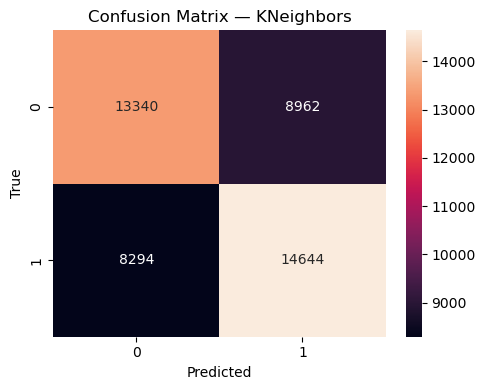

In [20]:
cm = confusion_matrix(y_test, knn_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix — KNeighbors")
plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

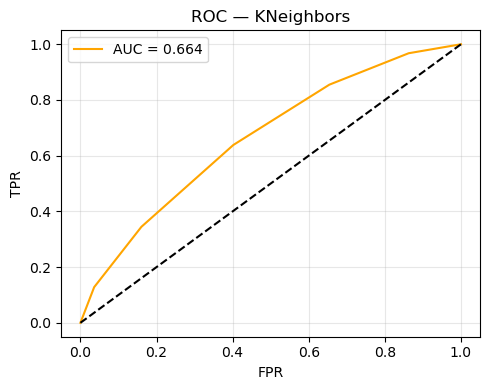

In [21]:
fpr, tpr, _ = roc_curve(y_test, knn_probs, pos_label=1)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}", color="orange")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — KNeighbors")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Вывод
Модель работает чуть лучше случайного угадывания. Метрики сбалансированы, но значения низкие. Для серьёзных задач слабовата, но как базовый вариант хорошо подойдет

### Дерево решений

In [22]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_probs = dt.predict_proba(X_test)[:, 1]

In [23]:
print(f"Accuracy : {accuracy_score(y_test, dt_preds):.4f}")
print(f"Precision: {precision_score(y_test, dt_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, dt_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, dt_preds, average='weighted', zero_division=0):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, dt_probs):.4f}\n")
print(classification_report(y_test, dt_preds, zero_division=0))

Accuracy : 0.5640
Precision: 0.6411
Recall   : 0.5640
F1-score : 0.4883
AUC-ROC  : 0.5737

              precision    recall  f1-score   support

          -1       0.74      0.18      0.28     22302
           1       0.54      0.94      0.69     22938

    accuracy                           0.56     45240
   macro avg       0.64      0.56      0.49     45240
weighted avg       0.64      0.56      0.49     45240



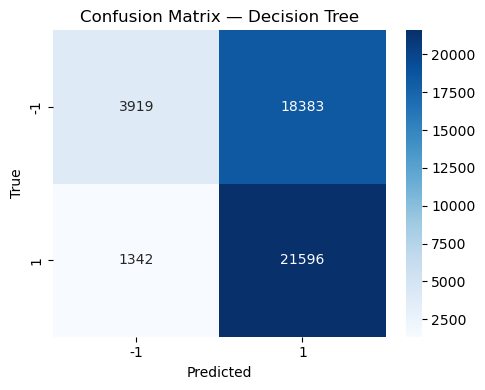

In [24]:
cm = confusion_matrix(y_test, dt_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["-1", "1"], yticklabels=["-1", "1"])
plt.title("Confusion Matrix — Decision Tree")
plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

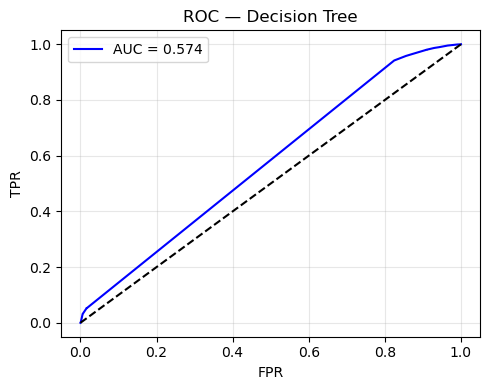

In [25]:
fpr, tpr, _ = roc_curve(y_test, dt_probs, pos_label=1)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}", color="blue")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — Decision Tree")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Вывод
Результаты несколько хуже, чем у предыдущей модели. Модель сильно перекошена: ловит 94% позитива, но пропускает 82% негатива, из-за чего общий F1 всего 0.49. Модель не смогла уловить закономерности в тексте.

### Случайный лес

In [26]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

In [27]:
print(f"Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"Precision: {precision_score(y_test, rf_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, rf_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, rf_preds, average='weighted', zero_division=0):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, rf_probs):.4f}\n")
print(classification_report(y_test, rf_preds, zero_division=0))

Accuracy : 0.7038
Precision: 0.7039
Recall   : 0.7038
F1-score : 0.7037
AUC-ROC  : 0.7745

              precision    recall  f1-score   support

          -1       0.71      0.68      0.69     22302
           1       0.70      0.72      0.71     22938

    accuracy                           0.70     45240
   macro avg       0.70      0.70      0.70     45240
weighted avg       0.70      0.70      0.70     45240



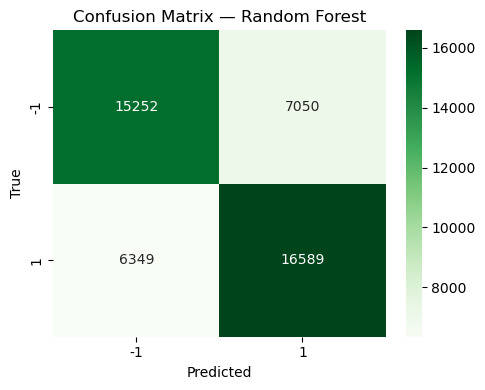

In [28]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=["-1", "1"], yticklabels=["-1", "1"])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

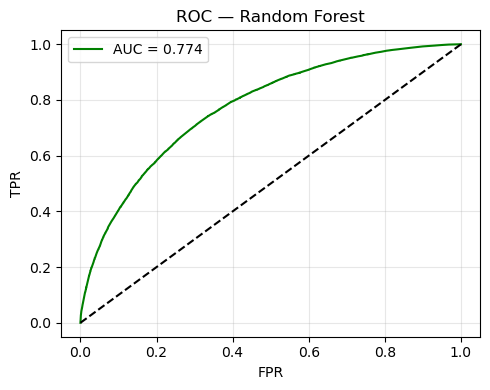

In [29]:
fpr, tpr, _ = roc_curve(y_test, rf_probs, pos_label=1)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}", color="green")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — Random Forest")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Вывод

Лучшая из трёх моделей по всем метрикам. Правильно определяет большинство постов, причём одинаково хорошо и позитив, и негатив. Метрики сбалансированы, модель стабильна, хорошо подходит под нашу задачу

### Сохранение лучшей модели

In [30]:
joblib.dump(rf, "sentiment_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
print("Модель и векторизатор сохранены.")

Модель и векторизатор сохранены.


### Обучение на новых данных

In [31]:
tmp = pd.read_csv('valid.csv', header=None, engine='python', nrows=2, on_bad_lines='skip')

new_raw = pd.read_csv('valid.csv', header=None, engine='python', on_bad_lines='skip')
new_df = pd.DataFrame({'text': new_raw.iloc[:, 1].astype(str)}) 

new_df['text_clean'] = new_df['text'].apply(preprocess_tweet)
new_df = new_df[new_df['text_clean'].str.len() > 0].reset_index(drop=True)
print(f"Загружено и очищено: {len(new_df)}")

Загружено и очищено: 21086


In [34]:
main_texts = dataset['text_clean'].tolist()
main_labels = dataset['sentiment'].tolist()

best_model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

# Пул новых данных для обогащения
pool_texts = new_df['text_clean'].tolist()
history = []

for i in range(3):
    if len(pool_texts) < 500:
        print("Пул иссяк. Повторяю цикл на оставшихся данных.")
        batch = pool_texts[:]
        pool_texts = []
    else:
        batch = pool_texts[:550]
        pool_texts = pool_texts[550:]

    # Объединяем основной корпус и новую пачку
    combined_texts = main_texts + batch

    # Снова проводим векторизацию на всём объединённом массиве
    X_combined = vectorizer.fit_transform(combined_texts)

    # Обучаем модель на размеченной части
    mask_labeled = [True]*len(main_texts) + [False]*len(batch)
    best_model.fit(X_combined[mask_labeled], main_labels)

    # Прогноз вероятностей для новой пачки
    X_batch = X_combined[len(main_texts):]
    probs = best_model.predict_proba(X_batch)[:, 1]

    # Вывод примеров для анализа
    if i == 0:
        print("\nПримеры вероятностей прогноза:")
        for t, p in zip(batch[:5], probs[:5]):
            status = "добавим" if (p > 0.8 or p < 0.2) else "пропустим"
            print(f"  [{t[:40]}...] -> p={p:.3f} {status}")

    pos_idx = np.where(probs > 0.8)[0]
    neg_idx = np.where(probs < 0.2)[0]
    accepted_idx = np.concatenate([pos_idx, neg_idx])

    main_texts.extend([batch[j] for j in accepted_idx])
    main_labels.extend([1]*len(pos_idx) + [-1]*len(neg_idx))

    acc = accuracy_score(main_labels, best_model.predict(X_combined[:len(main_labels)]))
    history.append({
        "Итерация": i+1,
        "Взято из пула": len(batch),
        "Добавлено в корпус": len(accepted_idx),
        "Размер корпуса": len(main_texts),
        "Точность на train": round(acc, 4)
    })
    print(f"Итерация {i+1}: Взято {len(batch)}, Добавлено {len(accepted_idx)}, Корпус: {len(main_texts)}")

print("\nИтог цикла:")
print(pd.DataFrame(history).to_string(index=False))


Примеры вероятностей прогноза:
  [развод деньга наблюдаться лайфклиника бе...] → p=0.177 добавим
  [отель выбрать рядом стадион отель номер ...] → p=0.659 пропустим
  [вылечить гноиться рождение глазик поликл...] → p=0.874 добавим
  [хороший расположениес вокзал дойти пешко...] → p=0.810 добавим
  [отличный месторасположениепрекрасный вид...] → p=0.883 добавим
Итерация 1: Взято 550, Добавлено 159, Корпус: 226359
Итерация 2: Взято 550, Добавлено 254, Корпус: 226613
Итерация 3: Взято 550, Добавлено 327, Корпус: 226940

Итог цикла:
 Итерация  Взято из пула  Добавлено в корпус  Размер корпуса  Точность на train
        1            550                 159          226359             0.9655
        2            550                 254          226613             0.9656
        3            550                 327          226940             0.9655


In [35]:
if len(pool_texts) > 0:
    print("\nПрогноз по оставшейся выборке:")
    X_remaining = vectorizer.transform(pool_texts)
    final_preds = best_model.predict(X_remaining)
    final_probs = best_model.predict_proba(X_remaining)[:, 1]

    print(f"Осталось текстов: {len(pool_texts)}")
    print(f"Распределение предсказаний: Позитив {(final_preds==1).sum()} | Негатив {(final_preds==-1).sum()}")
    print(f"Средняя уверенность: {np.max(best_model.predict_proba(X_remaining), axis=1).mean():.3f}")
else:
    print("\nВесь пул обработан и добавлен в корпус.")


Прогноз по оставшейся выборке:
Осталось текстов: 19436
Распределение предсказаний: Позитив 17412 | Негатив 2024
Средняя уверенность: 0.808


In [36]:
# Финальная валидация
final_preds = best_model.predict(X_test)
final_f1 = f1_score(y_test, final_preds, average='weighted')
final_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
print(f"Финальный F1: {final_f1:.4f} | AUC: {final_auc:.4f}")

Финальный F1: 0.5259 | AUC: 0.5384


#### Вывод
Изначально классификатор показывал стабильное качество (F1 = 0.70), но после цикла активного обучения метрики снизились до F1 = 0.52 из-за накопления шума при автоматической псевдоразметке. Модель начала постепенно переобучаться на собственных ошибочных предсказаниях. Тем не менее, показал необходимость дополнительной очистки данных для сохранения точности при правильном подходе